# Machine Learning — Empreinte Environnementale Alimentaire

**Objectif :** Prédire l'empreinte CO₂ alimentaire par pays/année/produit et identifier des profils de pays.

**Source :** Table `fait_impact_pays_annee` (Data Warehouse PostgreSQL)

**Variable cible :** `log1p(co2_total_kg)` (distribution log-normale confirmée en EDA)  
**Features :** `quantite_1000t`, `categorie`, `pib_per_capita`, `taux_urbanisation`, `population`, `surface_agricole`, `region`

## 4.1 — Setup & chargement

In [3]:
#pip install xgboost
#pip install mlflow

import pandas as pd
import numpy as np
import os
import joblib
from pathlib import Path
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

from scipy import stats

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import xgboost as xgb
import mlflow
import mlflow.sklearn

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

# Connexion PostgreSQL
load_dotenv('../.env')
PG_HOST = os.getenv('POSTGRES_HOST', 'localhost')
PG_PORT = os.getenv('POSTGRES_PORT', '5432')
PG_DB   = os.getenv('POSTGRES_DB',   'food_impact')
PG_USER = os.getenv('POSTGRES_USER', 'food_user')
PG_PASS = os.getenv('POSTGRES_PASSWORD', 'food_pass')

DB_URL = f"postgresql://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}"
engine = create_engine(DB_URL, echo=False)

def query_df(sql):
    return pd.read_sql(text(sql), engine)

# Dossier modèles
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

print("Setup OK")

C:\Users\Emeline\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup OK


In [4]:
df = query_df("""
    SELECT
        f.quantite_1000t,
        f.co2_total_kg,
        pr.categorie,
        p.region,
        s.pib_per_capita,
        s.taux_urbanisation,
        s.population,
        s.surface_agricole,
        p.code_iso3  AS iso3,
        p.nom_pays,
        t.annee
    FROM fait_impact_pays_annee f
    JOIN dim_pays     p  ON f.pays_id    = p.pays_id
    JOIN dim_temps    t  ON f.annee_id   = t.annee_id
    JOIN dim_produits pr ON f.produit_id = pr.produit_id
    LEFT JOIN dim_socio_economique s
           ON f.pays_id = s.pays_id AND f.annee_id = s.annee_id
    WHERE f.co2_total_kg IS NOT NULL
      AND f.quantite_1000t > 0
"""
)

print(f"Dataset brut : {len(df):,} lignes × {df.shape[1]} colonnes")
print(f"Valeurs manquantes :\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Dataset brut : 423,337 lignes × 11 colonnes
Valeurs manquantes :
region                9652
pib_per_capita       40325
taux_urbanisation    17000
population           17000
surface_agricole     19066
dtype: int64


## 4.2 — Feature engineering

Dataset ML : 372,597 lignes (après suppression NaN)
Catégories présentes — categorie : 15 | region : 5

Distribution log_co2 :
count    372597.00
mean         17.85
std           2.50
min          12.21
25%          16.02
50%          17.71
75%          19.53
max          28.32
Name: log_co2, dtype: float64


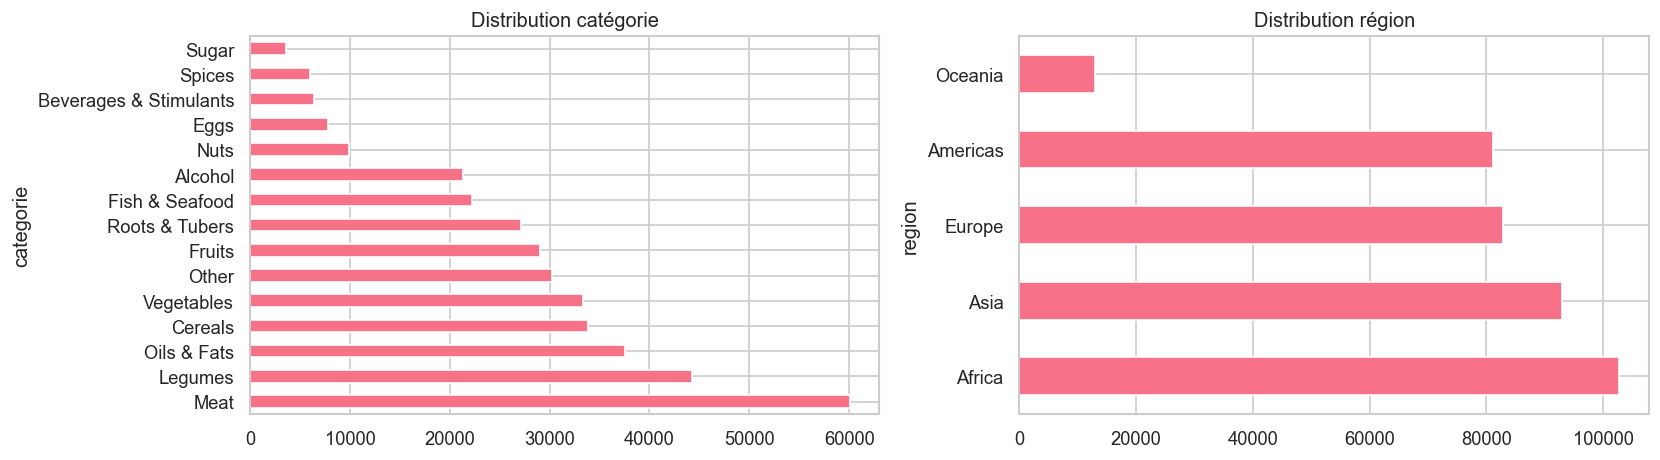

In [5]:
FEATURES_NUM = ['quantite_1000t', 'pib_per_capita', 'taux_urbanisation', 'population', 'surface_agricole']
FEATURES_CAT = ['categorie', 'region']
FEATURES     = FEATURES_NUM + FEATURES_CAT
TARGET       = 'co2_total_kg'

# Suppression des lignes avec NaN sur les features ou la cible
df_ml = df[FEATURES + [TARGET, 'iso3', 'nom_pays', 'annee']].dropna(subset=FEATURES + [TARGET])

# Variable cible log-transformée
df_ml = df_ml.copy()
df_ml['log_co2'] = np.log1p(df_ml[TARGET])

print(f"Dataset ML : {len(df_ml):,} lignes (après suppression NaN)")
print(f"Catégories présentes — categorie : {df_ml['categorie'].nunique()} | region : {df_ml['region'].nunique()}")
print(f"\nDistribution log_co2 :")
print(df_ml['log_co2'].describe().round(2))

# Vérification équilibre des catégories
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_ml['categorie'].value_counts().plot(kind='barh', ax=axes[0], title='Distribution catégorie')
df_ml['region'].value_counts().plot(kind='barh', ax=axes[1], title='Distribution région')
plt.tight_layout()
plt.show()

## 4.3 — Régression

Prédire `log1p(co2_total_kg)` à partir des features alimentaires et socio-économiques.

In [6]:
X = df_ml[FEATURES]
y = df_ml['log_co2']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train : {len(X_train):,} | Test : {len(X_test):,}")

# Préprocesseur
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), FEATURES_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES_CAT)
])

def eval_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    """Entraîne, évalue en CV et sur le test set."""
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    cv   = cross_val_score(pipeline, X_tr, y_tr, cv=5, scoring='r2', n_jobs=-1)
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"  RMSE   : {rmse:.4f}")
    print(f"  MAE    : {mae:.4f}")
    print(f"  R²     : {r2:.4f}")
    print(f"  CV R²  : {cv.mean():.4f} ± {cv.std():.4f}")
    return {'name': name, 'rmse': rmse, 'mae': mae, 'r2': r2, 'cv_r2_mean': cv.mean(), 'cv_r2_std': cv.std(), 'pipeline': pipeline, 'y_pred': y_pred}

results = {}

Train : 298,077 | Test : 74,520


In [7]:
# --- Baseline : Ridge ---
pipe_ridge = Pipeline([
    ('prep', preprocessor),
    ('model', Ridge(alpha=1.0))
])
results['Ridge'] = eval_model('Ridge (baseline)', pipe_ridge, X_train, y_train, X_test, y_test)


  Ridge (baseline)
  RMSE   : 2.1512
  MAE    : 1.7245
  R²     : 0.2660
  CV R²  : 0.2669 ± 0.0044


In [8]:
# --- RandomForest ---
pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE))
])
results['RandomForest'] = eval_model('RandomForest', pipe_rf, X_train, y_train, X_test, y_test)


  RandomForest
  RMSE   : 0.6839
  MAE    : 0.3618
  R²     : 0.9258
  CV R²  : 0.9276 ± 0.0010


In [9]:
# --- XGBoost ---
pipe_xgb = Pipeline([
    ('prep', preprocessor),
    ('model', xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    ))
])
results['XGBoost'] = eval_model('XGBoost', pipe_xgb, X_train, y_train, X_test, y_test)


  XGBoost
  RMSE   : 0.7810
  MAE    : 0.5713
  R²     : 0.9033
  CV R²  : 0.9029 ± 0.0011



=== Comparaison des modèles ===
                    rmse     mae      r2  cv_r2_mean  cv_r2_std
name                                                           
RandomForest      0.6839  0.3618  0.9258      0.9276     0.0010
XGBoost           0.7810  0.5713  0.9033      0.9029     0.0011
Ridge (baseline)  2.1512  1.7245  0.2660      0.2669     0.0044


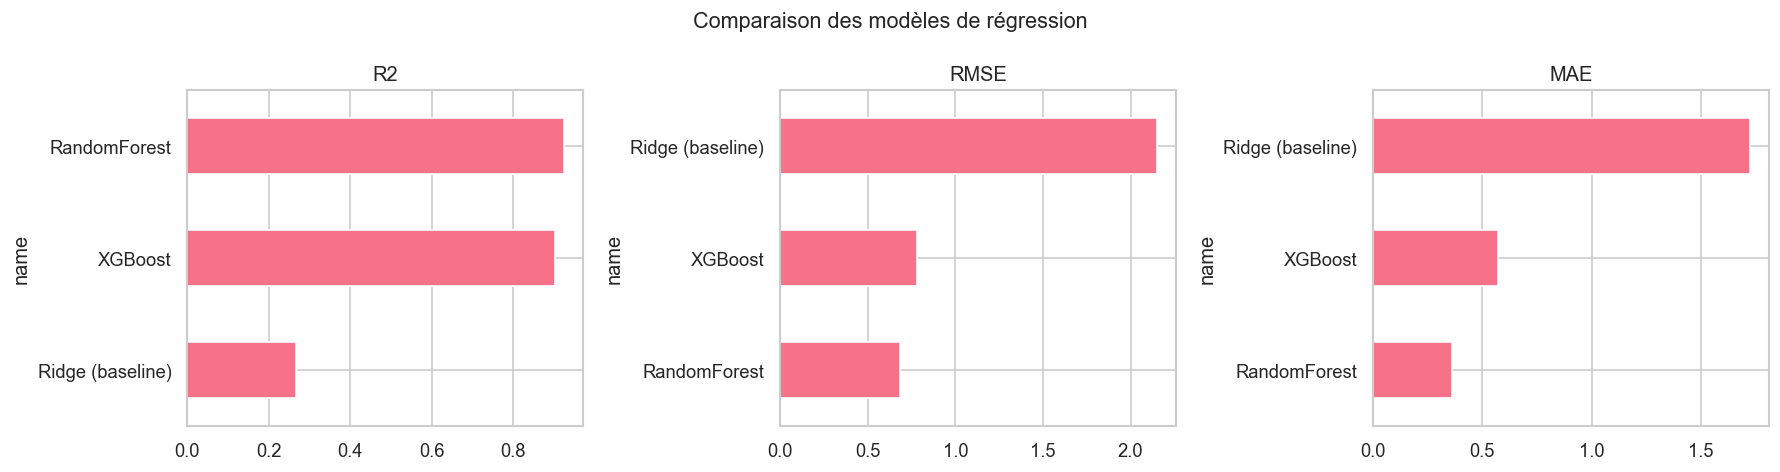


Meilleur modèle : RandomForest


In [10]:
# Comparaison des modèles
df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('pipeline', 'y_pred')}
    for r in results.values()
]).set_index('name').sort_values('r2', ascending=False)

print("\n=== Comparaison des modèles ===")
print(df_results[['rmse', 'mae', 'r2', 'cv_r2_mean', 'cv_r2_std']].round(4).to_string())

# Graphique
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['r2', 'rmse', 'mae']):
    df_results[metric].sort_values().plot(kind='barh', ax=ax, title=metric.upper())
plt.suptitle('Comparaison des modèles de régression', fontsize=13)
plt.tight_layout()
plt.show()

best_name = df_results['r2'].idxmax()
print(f"\nMeilleur modèle : {best_name}")

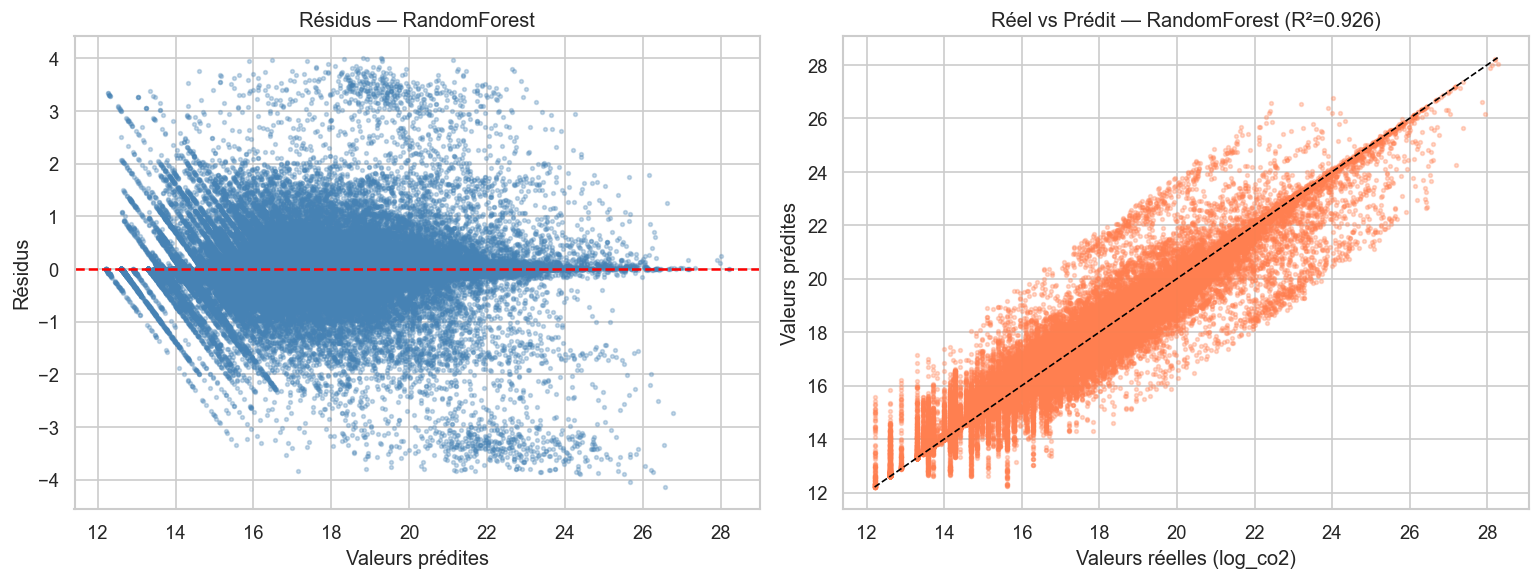

In [11]:
# Résidus du meilleur modèle
best = results[best_name]
y_pred = best['y_pred']
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred, residuals, alpha=0.3, s=5, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Valeurs prédites')
axes[0].set_ylabel('Résidus')
axes[0].set_title(f'Résidus — {best_name}')

axes[1].scatter(y_test, y_pred, alpha=0.3, s=5, color='coral')
lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lim, lim, 'k--', linewidth=1)
axes[1].set_xlabel('Valeurs réelles (log_co2)')
axes[1].set_ylabel('Valeurs prédites')
axes[1].set_title(f'Réel vs Prédit — {best_name} (R²={best["r2"]:.3f})')

plt.tight_layout()
plt.show()

## 4.4 — Fine-tuning & MLFlow

In [12]:
# Fine-tuning du meilleur modèle via RandomizedSearchCV
# (grid adapté selon le modèle sélectionné)

if best_name == 'XGBoost':
    param_dist = {
        'model__n_estimators':    [100, 200, 300],
        'model__max_depth':       [4, 6, 8],
        'model__learning_rate':   [0.05, 0.1, 0.2],
        'model__subsample':       [0.7, 0.8, 1.0],
        'model__colsample_bytree':[0.7, 0.8, 1.0],
    }
    base_pipeline = Pipeline([
        ('prep', preprocessor),
        ('model', xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0))
    ])
elif best_name == 'RandomForest':
    param_dist = {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth':    [None, 10, 20],
        'model__min_samples_split': [2, 5, 10],
        'model__max_features': ['sqrt', 'log2', 0.5],
    }
    base_pipeline = Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
    ])
else:  # Ridge
    param_dist = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
    base_pipeline = Pipeline([
        ('prep', preprocessor),
        ('model', Ridge())
    ])

search = RandomizedSearchCV(
    base_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)
search.fit(X_train, y_train)

print(f"\nMeilleurs paramètres : {search.best_params_}")
print(f"Meilleur R² CV      : {search.best_score_:.4f}")

best_pipeline = search.best_estimator_
y_pred_tuned = best_pipeline.predict(X_test)
rmse_t = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_t  = mean_absolute_error(y_test, y_pred_tuned)
r2_t   = r2_score(y_test, y_pred_tuned)
print(f"\nPerf test après tuning — RMSE={rmse_t:.4f} | MAE={mae_t:.4f} | R²={r2_t:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Meilleurs paramètres : {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__max_features': 0.5, 'model__max_depth': None}
Meilleur R² CV      : 0.9310

Perf test après tuning — RMSE=0.6659 | MAE=0.3697 | R²=0.9297


In [13]:
# MLFlow — tracking de tous les modèles + meilleur modèle tuné
mlflow.set_experiment('food_impact_regression')

# Log des modèles baseline
for name, res in results.items():
    with mlflow.start_run(run_name=name):
        mlflow.log_params({'model_type': name})
        mlflow.log_metrics({
            'rmse':       res['rmse'],
            'mae':        res['mae'],
            'r2':         res['r2'],
            'cv_r2_mean': res['cv_r2_mean'],
            'cv_r2_std':  res['cv_r2_std'],
        })
        mlflow.sklearn.log_model(res['pipeline'], artifact_path='model')

# Log du meilleur modèle tuné
with mlflow.start_run(run_name=f'{best_name}_tuned'):
    mlflow.log_params(search.best_params_)
    mlflow.log_params({'model_type': best_name, 'tuned': True})
    mlflow.log_metrics({'rmse': rmse_t, 'mae': mae_t, 'r2': r2_t, 'cv_r2_mean': search.best_score_})
    mlflow.sklearn.log_model(best_pipeline, artifact_path='model')
    mlflow.set_tag('best_model', 'true')

print("MLFlow — expériences enregistrées.")
print("Pour visualiser : mlflow ui  (depuis le dossier racine)")

2026/03/04 21:03:00 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/04 21:03:00 INFO mlflow.store.db.utils: Updating database tables
2026/03/04 21:03:01 INFO mlflow.tracking.fluent: Experiment with name 'food_impact_regression' does not exist. Creating a new experiment.
2026/03/04 21:03:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/04 21:03:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/04 21:03:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/04 21:03:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickl

MLFlow — expériences enregistrées.
Pour visualiser : mlflow ui  (depuis le dossier racine)


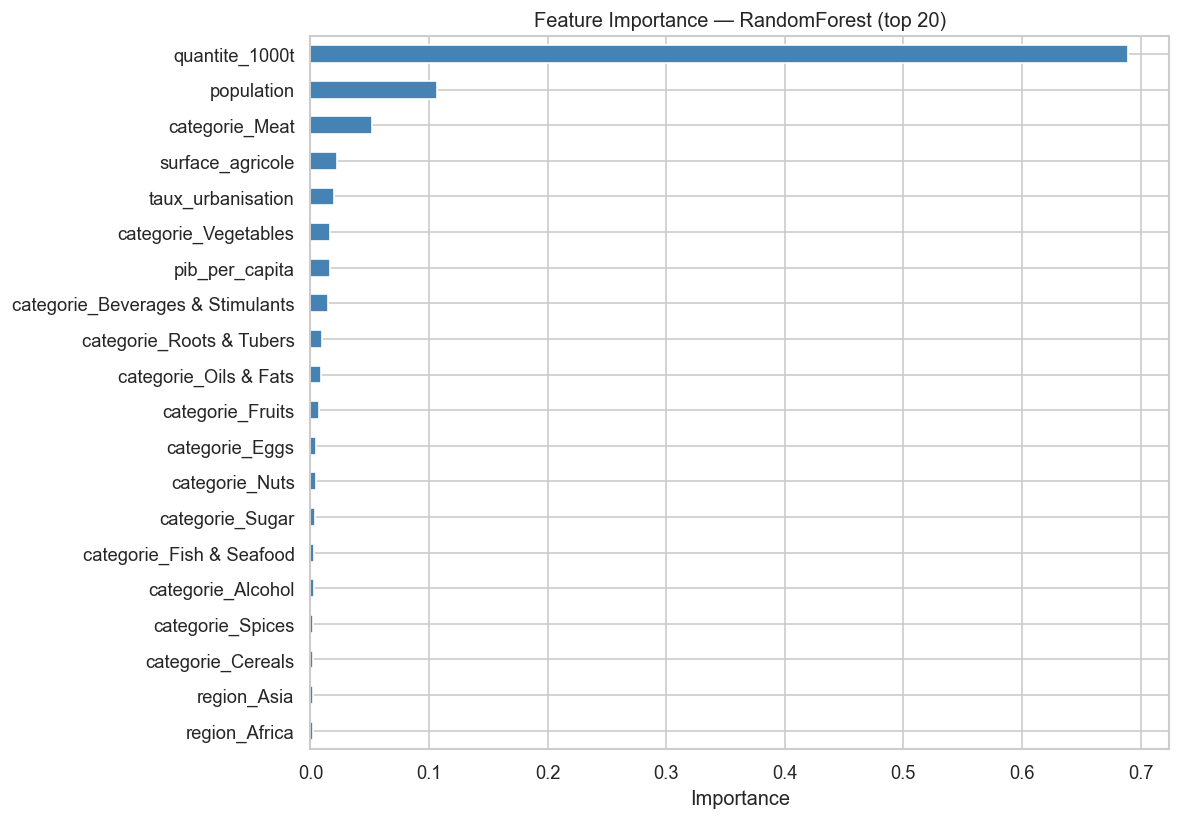


Top 10 features :
quantite_1000t                      0.6894
population                          0.1067
categorie_Meat                      0.0518
surface_agricole                    0.0220
taux_urbanisation                   0.0201
categorie_Vegetables                0.0167
pib_per_capita                      0.0165
categorie_Beverages & Stimulants    0.0148
categorie_Roots & Tubers            0.0100
categorie_Oils & Fats               0.0085


In [14]:
# Feature importance (pour RandomForest et XGBoost)
model_step = best_pipeline.named_steps['model']

if hasattr(model_step, 'feature_importances_'):
    # Récupérer les noms de features après OneHotEncoder
    ohe_features = best_pipeline.named_steps['prep']\
        .named_transformers_['cat']\
        .get_feature_names_out(FEATURES_CAT).tolist()
    all_features = FEATURES_NUM + ohe_features

    importances = pd.Series(model_step.feature_importances_, index=all_features)\
        .sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, max(4, len(importances[:20]) * 0.35)))
    importances[:20].sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Feature Importance — {best_name} (top 20)')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print("\nTop 10 features :")
    print(importances.head(10).round(4).to_string())
else:
    print(f"Feature importance non disponible pour {best_name}")

In [15]:
# Sauvegarde du modèle
model_path = MODELS_DIR / 'model_impact.pkl'
joblib.dump(best_pipeline, model_path)
print(f"Modèle sauvegardé : {model_path}")

# Vérification : rechargement et prédiction test
loaded = joblib.load(model_path)
y_check = loaded.predict(X_test[:5])
print(f"Vérification chargement OK — prédictions : {np.expm1(y_check).round(0)}")

Modèle sauvegardé : ..\models\model_impact.pkl
Vérification chargement OK — prédictions : [1.05554629e+10 2.80380800e+06 4.20362000e+06 4.14180673e+08
 6.34009021e+08]


## 4.5 — Clustering : profils de pays

Objectif : regrouper les pays selon leur profil alimentaire et socio-économique.
On agrège au niveau **pays × année** pour avoir une ligne par pays/an.

In [16]:
# Agrégation pays × année
ANIMAL_CATS = ['Meat', 'Dairy', 'Eggs', 'Fish & Seafood']

df_agg = df_ml.copy()
df_agg['co2_animal'] = df_agg['co2_total_kg'].where(df_agg['categorie'].isin(ANIMAL_CATS), 0)

df_pays = (
    df_agg.groupby(['iso3', 'nom_pays', 'annee', 'region',
                    'pib_per_capita', 'taux_urbanisation',
                    'population', 'surface_agricole'])
    .agg(
        co2_total=('co2_total_kg', 'sum'),
        co2_animal=('co2_animal', 'sum'),
        quantite_total=('quantite_1000t', 'sum')
    )
    .reset_index()
)

df_pays['co2_per_capita']  = df_pays['co2_total'] / df_pays['population'].replace(0, np.nan)
df_pays['pct_animal']      = df_pays['co2_animal'] / (df_pays['co2_total'] + 1e-10) * 100

CLUSTER_FEATURES = ['co2_per_capita', 'pib_per_capita', 'taux_urbanisation', 'pct_animal', 'surface_agricole']
df_clust = df_pays[CLUSTER_FEATURES + ['iso3', 'nom_pays', 'annee', 'region']].dropna(subset=CLUSTER_FEATURES)

print(f"Dataset clustering : {len(df_clust):,} lignes pays×année")
print(df_clust[CLUSTER_FEATURES].describe().round(2))

Dataset clustering : 8,184 lignes pays×année
       co2_per_capita  pib_per_capita  taux_urbanisation  pct_animal  \
count         8184.00         8184.00            8184.00     8184.00   
mean          2708.45         7325.56              51.19       31.22   
std           1501.56        13918.08              23.63       16.56   
min            387.28           11.80               2.67        1.19   
25%           1575.67          550.62              31.41       17.33   
50%           2510.46         1748.60              52.53       32.55   
75%           3546.94         6653.54              69.99       43.77   
max           9735.53       134965.82             100.00       82.31   

       surface_agricole  
count           8184.00  
mean              38.81  
std               20.91  
min                0.26  
25%               21.58  
50%               38.81  
75%               55.04  
max               93.44  


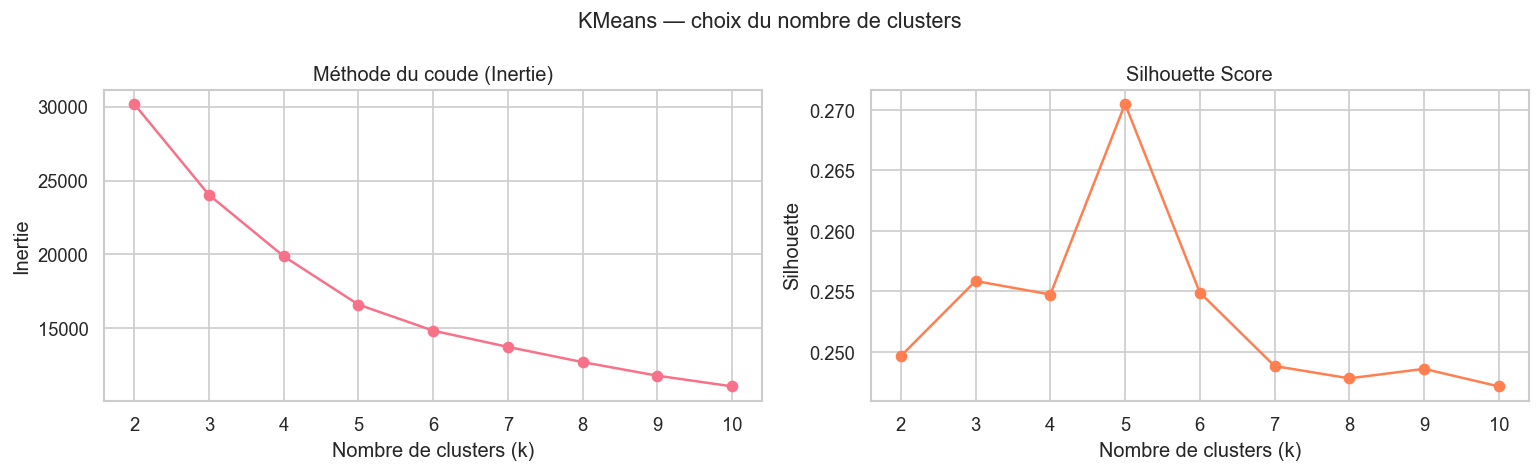


Meilleur k selon Silhouette : 5 (score=0.270)


In [17]:
# KMeans — méthode du coude + silhouette
X_clust = StandardScaler().fit_transform(df_clust[CLUSTER_FEATURES])

inertias, silhouettes = [], []
K_RANGE = range(2, 11)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(K_RANGE), inertias, marker='o')
axes[0].set_title('Méthode du coude (Inertie)')
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie')

axes[1].plot(list(K_RANGE), silhouettes, marker='o', color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Silhouette')

plt.suptitle('KMeans — choix du nombre de clusters', fontsize=13)
plt.tight_layout()
plt.show()

best_k = list(K_RANGE)[np.argmax(silhouettes)]
print(f"\nMeilleur k selon Silhouette : {best_k} (score={max(silhouettes):.3f})")

In [18]:
# KMeans final
# Ajuster K_FINAL si le coude suggère un k différent du max silhouette
K_FINAL = best_k

km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
df_clust = df_clust.copy()
df_clust['cluster_km'] = km_final.fit_predict(X_clust)

sil = silhouette_score(X_clust, df_clust['cluster_km'])
print(f"KMeans k={K_FINAL} — Silhouette Score : {sil:.3f}")

# Profils des clusters
print("\nProfils moyens par cluster :")
print(
    df_clust.groupby('cluster_km')[CLUSTER_FEATURES]
    .mean().round(1).to_string()
)

print("\nNombre d'observations par cluster :")
print(df_clust['cluster_km'].value_counts().sort_index())

KMeans k=5 — Silhouette Score : 0.270

Profils moyens par cluster :
            co2_per_capita  pib_per_capita  taux_urbanisation  pct_animal  surface_agricole
cluster_km                                                                                 
0                   4894.8          1017.5               32.5         8.6              38.9
1                   2941.7          7308.2               67.8        39.0              59.7
2                   3329.7         48672.1               81.9        47.3              32.6
3                   2372.7          8019.3               67.5        41.7              18.8
4                   1466.4           914.2               31.4        27.0              38.5

Nombre d'observations par cluster :
cluster_km
0    1381
1    1876
2     587
3    1731
4    2609
Name: count, dtype: int64


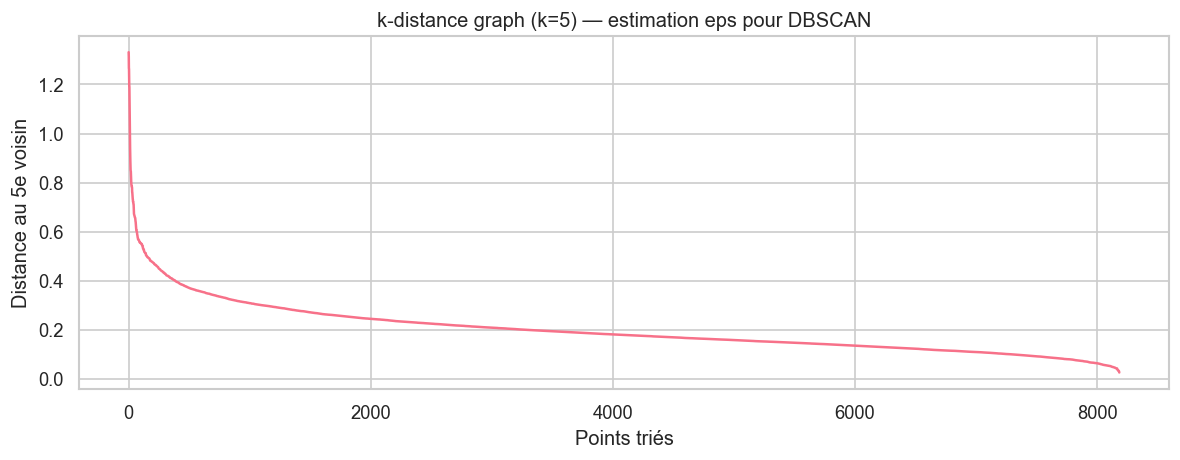

DBSCAN (eps=1.5, min_samples=5) : 1 clusters, 0 outliers (0.0%)
cluster_db
0    8184
Name: count, dtype: int64


In [19]:
# DBSCAN — détection de clusters de densité + outliers
from sklearn.neighbors import NearestNeighbors

# Estimation eps avec k-distance graph
nbrs = NearestNeighbors(n_neighbors=5).fit(X_clust)
distances, _ = nbrs.kneighbors(X_clust)
k_distances = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_distances)
ax.set_title('k-distance graph (k=5) — estimation eps pour DBSCAN')
ax.set_xlabel('Points triés')
ax.set_ylabel('Distance au 5e voisin')
plt.tight_layout()
plt.show()

# DBSCAN
db = DBSCAN(eps=1.5, min_samples=5)
df_clust['cluster_db'] = db.fit_predict(X_clust)

n_clusters_db = len(set(df_clust['cluster_db'])) - (1 if -1 in df_clust['cluster_db'].values else 0)
n_outliers    = (df_clust['cluster_db'] == -1).sum()
print(f"DBSCAN (eps=1.5, min_samples=5) : {n_clusters_db} clusters, {n_outliers} outliers ({n_outliers/len(df_clust)*100:.1f}%)")
print(df_clust['cluster_db'].value_counts().sort_index())

In [20]:
# Visualisation 2D par PCA (KMeans)
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca2.fit_transform(X_clust)
df_clust['PC1'] = coords[:, 0]
df_clust['PC2'] = coords[:, 1]

print(f"Variance expliquée : PC1={pca2.explained_variance_ratio_[0]:.1%}, PC2={pca2.explained_variance_ratio_[1]:.1%}")

# Focus sur la dernière année disponible pour lisibilité
annee_ref = df_clust['annee'].max()
df_viz = df_clust[df_clust['annee'] == annee_ref].copy()

fig = px.scatter(
    df_viz,
    x='PC1', y='PC2',
    color=df_viz['cluster_km'].astype(str),
    hover_name='nom_pays',
    hover_data=['pib_per_capita', 'taux_urbanisation', 'pct_animal'],
    title=f'Clusters KMeans (k={K_FINAL}) — Pays {annee_ref} (PCA 2D)',
    labels={'color': 'Cluster'}
)
fig.show()

# Carte mondiale des clusters
fig_map = px.choropleth(
    df_viz,
    locations='iso3',
    color=df_viz['cluster_km'].astype(str),
    hover_name='nom_pays',
    title=f'Profils de pays — KMeans k={K_FINAL} ({annee_ref})',
    labels={'color': 'Cluster'}
)
fig_map.update_layout(geo=dict(showframe=False))
fig_map.show()

Variance expliquée : PC1=39.6%, PC2=24.8%


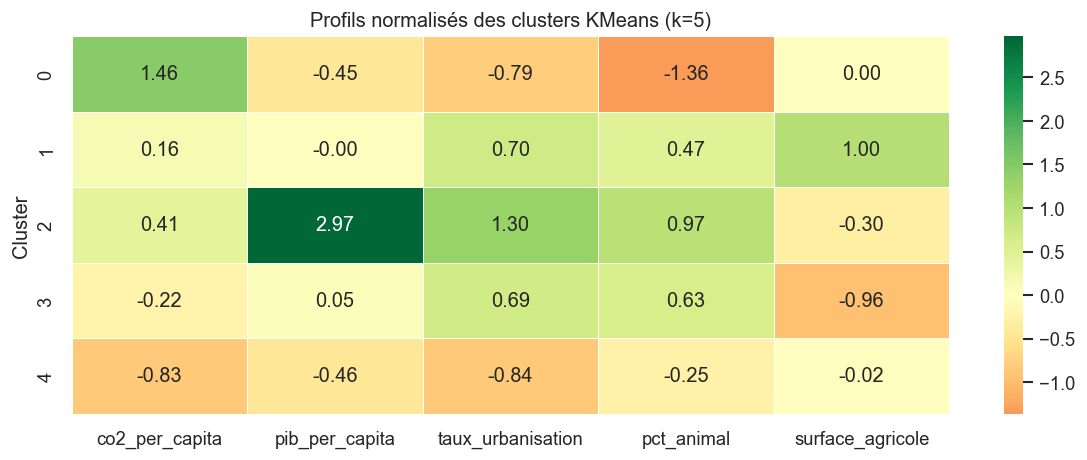


Régions dominantes par cluster :
region      Africa  Americas  Asia  Europe  Oceania
cluster_km                                         
0             1018       115    50      29      169
1              192       462   277     859       86
2                0        50   117     380       40
3              105       731   515     344       36
4             1039       436   993      73       68

Modèle KMeans sauvegardé.


In [21]:
# Radar / heatmap des profils de clusters
scaler_viz = StandardScaler()
df_clust_scaled = df_clust.copy()
df_clust_scaled[CLUSTER_FEATURES] = scaler_viz.fit_transform(df_clust[CLUSTER_FEATURES])

cluster_means = df_clust_scaled.groupby('cluster_km')[CLUSTER_FEATURES].mean()

fig, ax = plt.subplots(figsize=(10, max(3, K_FINAL * 0.8)))
sns.heatmap(
    cluster_means,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title(f'Profils normalisés des clusters KMeans (k={K_FINAL})')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

# Régions dominantes par cluster
print("\nRégions dominantes par cluster :")
print(
    df_clust.groupby(['cluster_km', 'region'])
    .size()
    .unstack(fill_value=0)
    .to_string()
)

# Sauvegarde du modèle de clustering
joblib.dump(km_final, MODELS_DIR / 'model_clustering.pkl')
print("\nModèle KMeans sauvegardé.")

## 4.6 — Conclusions

In [23]:
print("=" * 60)
print("SYNTHÈSE MACHINE LEARNING")
print("=" * 60)

print("\n--- Régression (log_co2_total_kg) ---")
print(df_results[['rmse', 'mae', 'r2', 'cv_r2_mean']].round(4).to_string())
print(f"\nMeilleur modèle : {best_name}")
print(f"Après tuning   : RMSE={rmse_t:.4f} | R²={r2_t:.4f}")

print("\n--- Clustering ---")
print(f"KMeans k={K_FINAL} — Silhouette Score : {sil:.3f}")
print(f"DBSCAN         — {n_clusters_db} clusters, {n_outliers} outliers")

print("\n--- Modèles sauvegardés ---")
print(f"  models/model_impact.pkl      (régression)")
print(f"  models/model_clustering.pkl  (clustering)")

SYNTHÈSE MACHINE LEARNING

--- Régression (log_co2_total_kg) ---
                    rmse     mae      r2  cv_r2_mean
name                                                
RandomForest      0.6839  0.3618  0.9258      0.9276
XGBoost           0.7810  0.5713  0.9033      0.9029
Ridge (baseline)  2.1512  1.7245  0.2660      0.2669

Meilleur modèle : RandomForest
Après tuning   : RMSE=0.6659 | R²=0.9297

--- Clustering ---
KMeans k=5 — Silhouette Score : 0.270
DBSCAN         — 1 clusters, 0 outliers

--- Modèles sauvegardés ---
  models/model_impact.pkl      (régression)
  models/model_clustering.pkl  (clustering)


### Synthèse ML

**Dataset :** 372 597 observations après suppression des NaN (sur 423 337 brutes) · 80/20 train/test

---

**Régression — prédiction de `log1p(co2_total_kg)` :**

| Modèle | RMSE | MAE | R² test | CV R² (5-fold) |
|--------|------|-----|---------|----------------|
| Ridge (baseline) | 2.1512 | 1.7245 | 0.266 | 0.267 ± 0.004 |
| XGBoost | 0.7810 | 0.5713 | 0.903 | 0.903 ± 0.001 |
| **RandomForest** | **0.6839** | **0.3618** | **0.926** | **0.928 ± 0.001** |

→ Ridge très insuffisant (R²=0.27) : la relation CO2 ~ features est fortement non-linéaire.  
→ **RandomForest** meilleur modèle : R²=0.926, faible variance CV (±0.001).

**Après fine-tuning** (RandomizedSearchCV, 20 iters, CV=5) :  
Params optimaux : `n_estimators=200, min_samples_split=5, max_features=0.5, max_depth=None`  
→ RMSE=**0.6659** | R²=**0.9297** | CV R²=0.9310

---

**Clustering — profils de pays×année (5 features) :**

KMeans k=5 retenu (Silhouette=0.270) · PCA 2D : PC1=39.6%, PC2=24.8%

| Cluster | n | CO₂/hab (kg) | PIB/hab ($) | Urbanisation | % Animal | Surface agri |
|---------|---|-------------|------------|-------------|----------|-------------|
| 0 | 1 381 | 4 895 | 1 018 | 32.5% | **8.6%** | 38.9% |
| 1 | 1 876 | 2 942 | 7 308 | 67.8% | 39.0% | 59.7% |
| 2 | 587 | 3 330 | **48 672** | **81.9%** | 47.3% | 32.6% |
| 3 | 1 731 | 2 373 | 8 019 | 67.5% | 41.7% | 18.8% |
| 4 | 2 609 | **1 466** | 914 | 31.4% | 27.0% | 38.5% |

Interprétation des profils :
- **Cluster 0** — *Producteurs agricoles intensifs* : CO₂/hab élevé malgré faible PIB et faible part animale → dominé par la production massive de tubercules/racines (Roots & Tubers, 1er cumulé en EDA)
- **Cluster 1** — *Pays en développement agricole* : PIB intermédiaire, agriculture étendue, part animale modérée
- **Cluster 2** — *Pays riches, régime animal* : PIB très élevé (48 672 $/hab), très urbains, part animale la plus forte — cohérent avec H1 validée en EDA
- **Cluster 3** — *Pays émergents urbains* : PIB moyen, très urbanisés, peu de surface agricole → importateurs nets
- **Cluster 4** — *Pays à faible revenu* : CO₂/hab le plus bas, peu urbanisés, faible part animale — correspondant aux Q1 de l'EDA

DBSCAN (eps=1.5) : 1 cluster unique, 0 outliers → eps trop large pour ce dataset, à retuner via le k-distance graph avant usage en production.

---

**Modèles sauvegardés :**
- `models/model_impact.pkl` — RandomForest tuné (régression)
- `models/model_clustering.pkl` — KMeans k=5